In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.preprocessing import StandardScaler


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UCI_Credit_Card.csv')

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default.payment.next.month'],
      dtype='object')

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

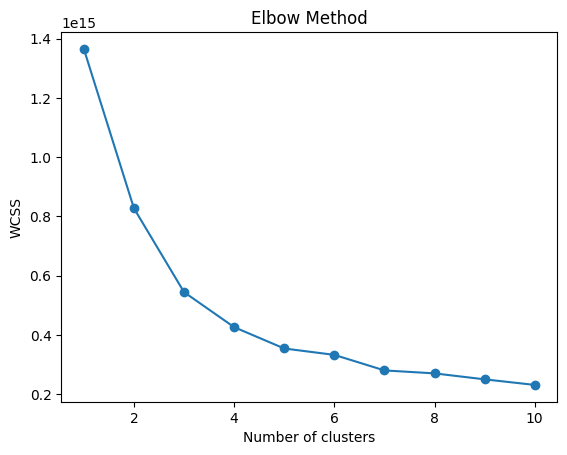

In [7]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [8]:
kmeansss = KMeans(n_clusters=3)
kmeansss.fit(df)

KMeans(n_clusters=3)

In [9]:
cluster = kmeansss.predict(df)

In [10]:
df['cluster'] = cluster

In [11]:
df.sample(n=10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,cluster
29055,29056,100000.0,2,3,1,57,0,0,0,0,...,101475.0,100558.0,4000.0,4000.0,4000.0,4000.0,4000.0,4000.0,0,1
17340,17341,200000.0,2,1,2,32,-2,-2,-2,-2,...,146948.0,148772.0,0.0,1685.0,326974.0,5200.0,5500.0,6000.0,0,2
9158,9159,20000.0,1,2,2,34,0,0,2,0,...,19315.0,20836.0,2500.0,1000.0,1000.0,1000.0,2000.0,0.0,0,1
3013,3014,180000.0,2,1,2,28,-2,-2,-2,-2,...,916.0,1189.0,1133.0,572.0,803.0,916.0,1189.0,375.0,0,1
3834,3835,50000.0,2,3,1,25,2,2,0,0,...,30099.0,28041.0,0.0,1833.0,1000.0,1000.0,10000.0,10000.0,1,1
28229,28230,400000.0,2,2,2,35,2,0,0,0,...,213831.0,210563.0,50016.0,120018.0,10071.0,8037.0,8018.0,8809.0,1,0
24828,24829,310000.0,1,2,1,41,-2,-2,-2,-2,...,-56.0,-56.0,23712.0,0.0,5359.0,0.0,0.0,0.0,0,2
23478,23479,110000.0,2,1,2,32,-1,0,0,0,...,21994.0,8391.0,12000.0,5000.0,3000.0,3000.0,2000.0,1000.0,0,1
4809,4810,500000.0,1,3,3,53,0,0,0,0,...,126650.0,114473.0,12602.0,11000.0,4711.0,6000.0,11000.0,10000.0,0,0
403,404,30000.0,1,2,1,48,0,0,0,0,...,25667.0,26179.0,1774.0,1710.0,1046.0,1079.0,1089.0,2244.0,0,1


In [14]:
bill_columns = ["BILL_AMT1","BILL_AMT2","BILL_AMT3",
                "BILL_AMT4","BILL_AMT5","BILL_AMT6"]

In [15]:
df["AVG_BILL"] = df[bill_columns].mean(axis=1)

df.groupby("cluster")["AVG_BILL"].mean()


,AVG_BILL
cluster,
0,183617.700441
1,29460.678418
2,17986.407572


In [16]:
df.groupby("cluster")["LIMIT_BAL"].mean()


,LIMIT_BAL
cluster,
0,274713.017621
1,82576.736494
2,307344.433641


In [17]:
cluster_profiles = df.groupby("cluster")[["LIMIT_BAL", "AVG_BILL"]].mean().round(2)

cluster_profiles


,LIMIT_BAL,AVG_BILL
cluster,,
0,274713.02,183617.70
1,82576.74,29460.68
2,307344.43,17986.41


In [ ]:
cluster_labels = {
    1: "High Value (Safe Customers)",
    2: "Moderate Customers",
    0: "High Risk Customers"
}


In [ ]:
df["cluster"] = df["cluster"].map(cluster_labels)


In [ ]:
cluster_profiles = cluster_profiles.reset_index()

cluster_profiles["cluster"] = cluster_profiles["cluster"].map(cluster_labels)

cluster_profiles


,cluster,LIMIT_BAL,AVG_BILL
0,High Risk Customers,82454.14,29330.68
1,High Value (Safe Customers),273750.05,182937.93
2,Moderate Customers,307331.31,17934.18
